# Домашнее задание 1

Реализуйте три алгоритма:
1. **OVA (One-vs-All)** - мультиклассовая классификация через K бинарных классификаторов
2. **AVA (All-vs-All)** - мультиклассовая классификация через K(K-1)/2 бинарных классификаторов
3. **LARS (Least Angle Regression)** - алгоритм построения пути регрессионных коэффициентов

Проверка: `uv run python -m unittest tests/*.py`

In [75]:
matplotlib.pyplot
%matplotlib inline

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from copy import deepcopy
from itertools import combinations
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, make_regression
from sklearn.metrics import accuracy_score
from sklearn.base import clone
from matplotlib.colors import ListedColormap

## 1. One-vs-All (OVA)

Стратегия OVA (она же One-vs-Rest, OVR):
- Для задачи с K классами обучаем K бинарных классификаторов
- Классификатор $k$ обучается отличать класс $k$ от всех остальных
- При предсказании выбираем класс с наибольшей уверенностью (confidence)

Реализуйте класс `OVAClassifier`. В качестве базового классификатора используйте sklearn `LogisticRegression`.

In [76]:
class OVAClassifier:
    def __init__(self, base_clf=None):
        self.base_clf = base_clf if base_clf is not None else LogisticRegression(max_iter=1000)
        self.classes_ = None
        self.classifiers_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.classifiers_ = []

        for cls in self.classes_:
            clf = deepcopy(self.base_clf)
            y_binary = (y == cls).astype(int)
            clf.fit(X, y_binary)
            self.classifiers_.append(clf)

        return self

    def predict(self, X):
        scores = []

        for clf in self.classifiers_:
            if hasattr(clf, "decision_function"):
                score = clf.decision_function(X)
            else:
                score = clf.predict_proba(X)[:, 1]
            scores.append(score)

        scores = np.column_stack(scores)
        best_class_idx = np.argmax(scores, axis=1)
        return self.classes_[best_class_idx]


### Проверка OVA

In [77]:
# Генерируем 4-класcовые 2D данные для визуализации
if __name__ != "homework":
    X_vis, y_vis = make_classification(
        n_samples=300, n_features=2, n_informative=2, n_redundant=0,
        n_classes=4, n_clusters_per_class=1, random_state=42,
    )
    X_vis_train, X_vis_test = X_vis[:200], X_vis[200:]
    y_vis_train, y_vis_test = y_vis[:200], y_vis[200:]

In [78]:
def plot_decision_boundary(clf, X, y, ax, title):
    """Plot decision regions for a multiclass classifier on 2D data."""
    eps = 0.5
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - eps, X[:, 0].max() + eps, 300),
        np.linspace(X[:, 1].min() - eps, X[:, 1].max() + eps, 300),
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cmap_bg = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA'])
    ax.pcolormesh(xx, yy, Z, cmap=cmap_bg, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', edgecolors='k', s=30)
    ax.set_title(title)
    ax.grid(alpha=0.2)

# Helper is always defined, but check cells below only run interactively

/var/folders/l0/b18kzzsj259b8dxlk_55vhnm0000gn/T/ipykernel_81190/1346890034.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))


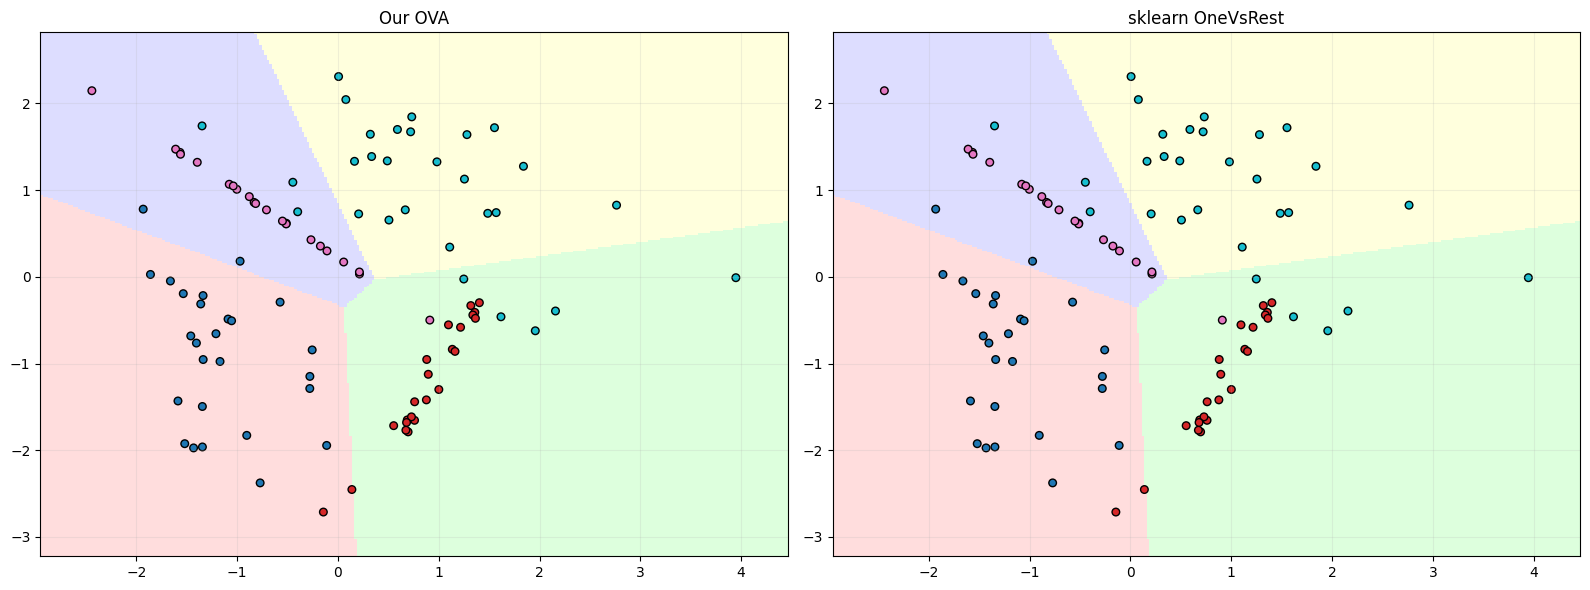

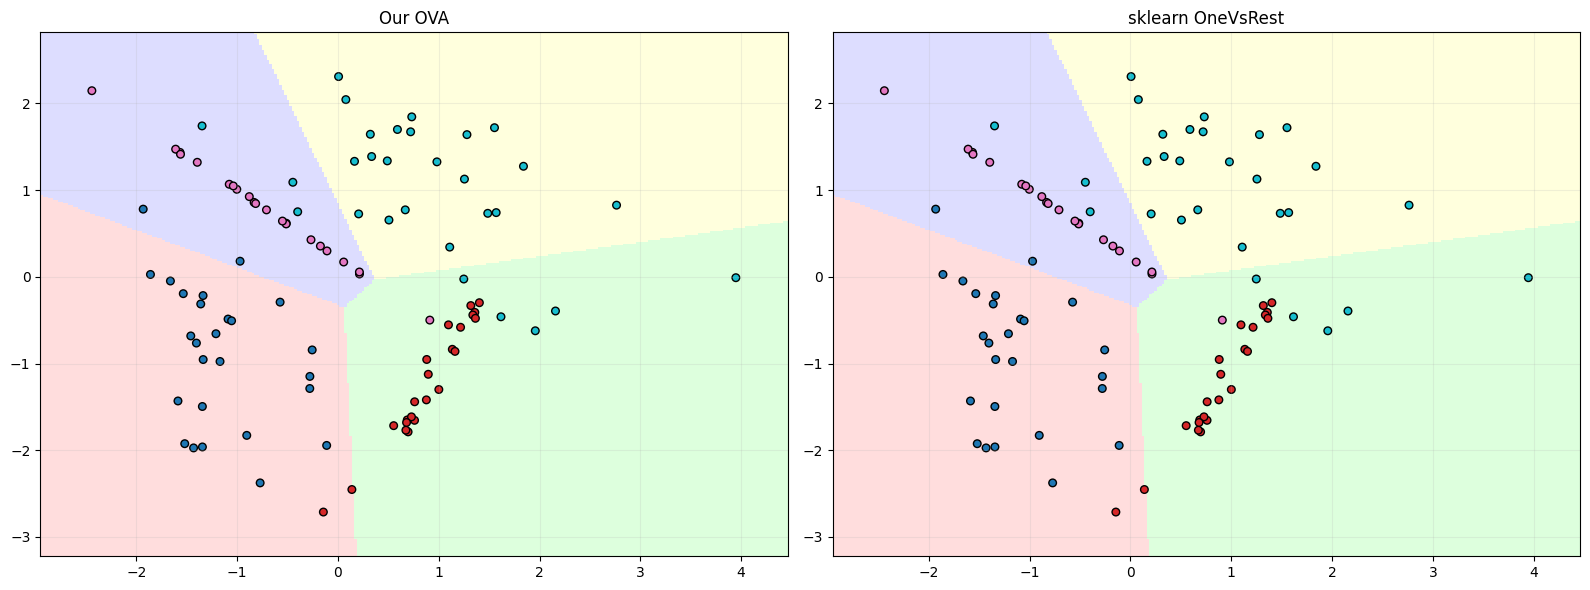

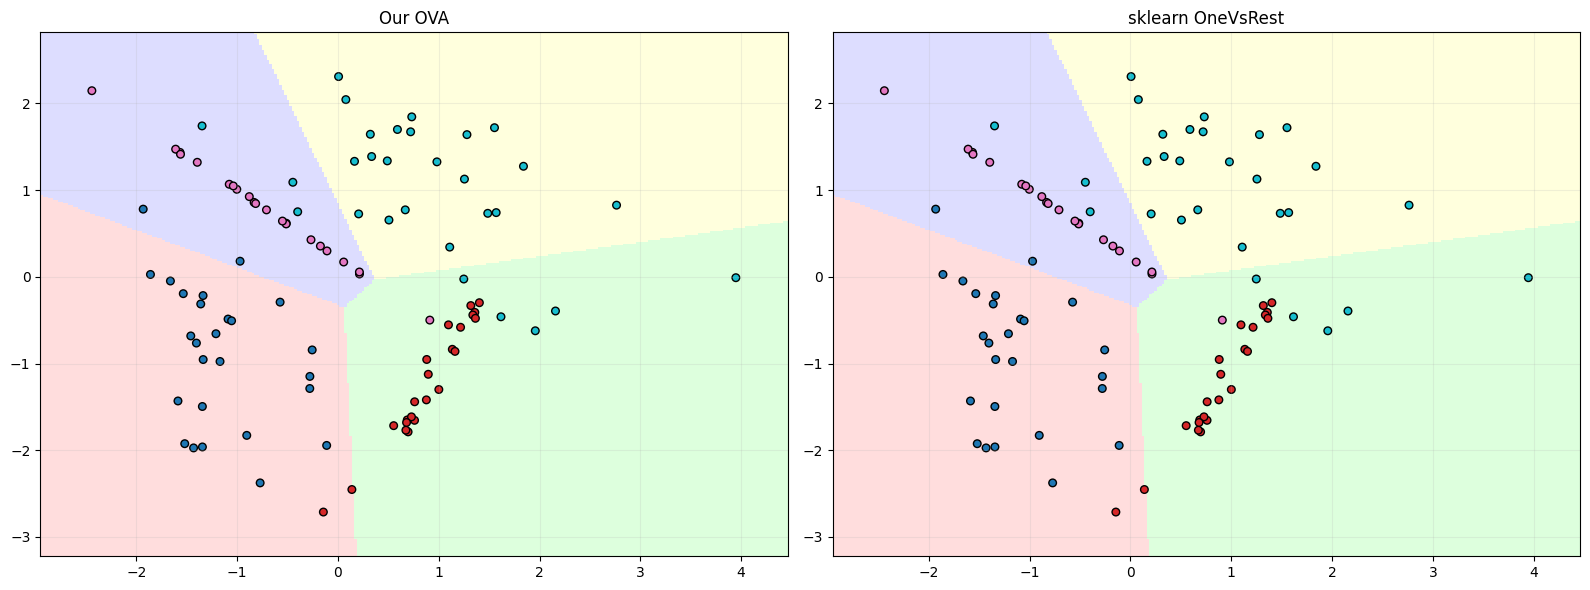

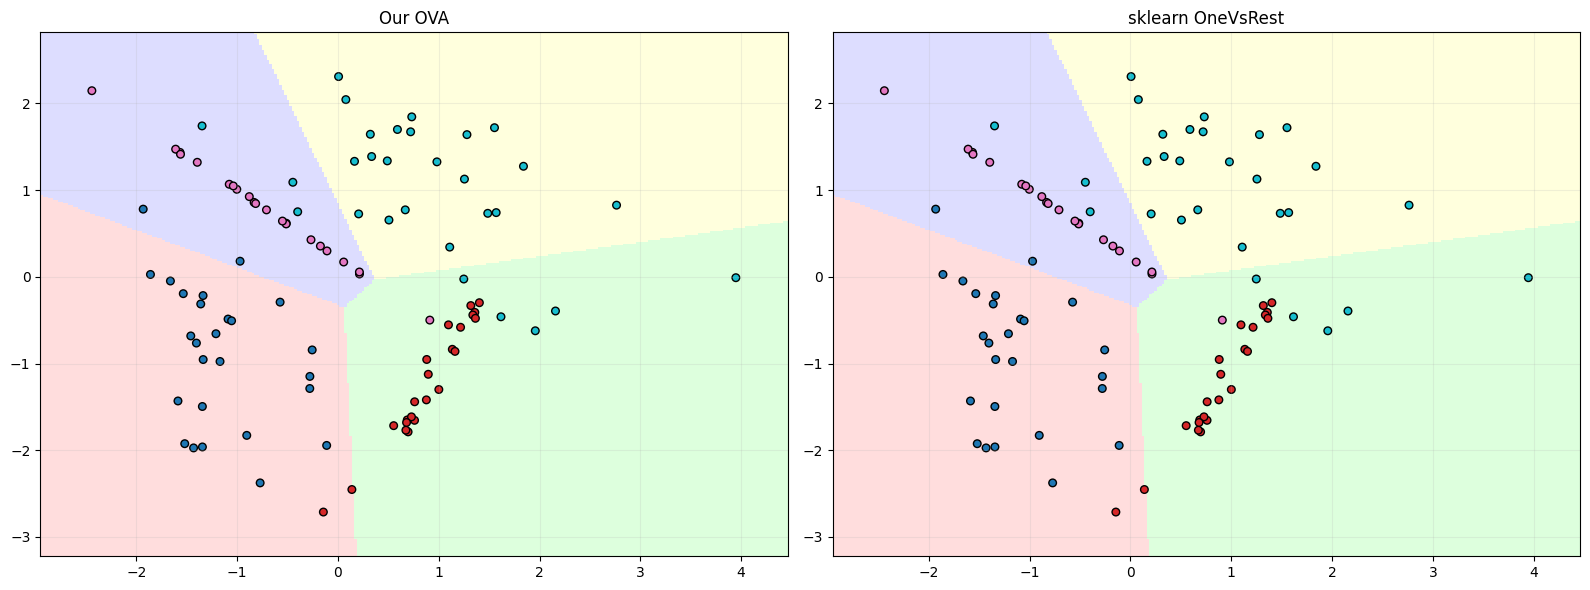

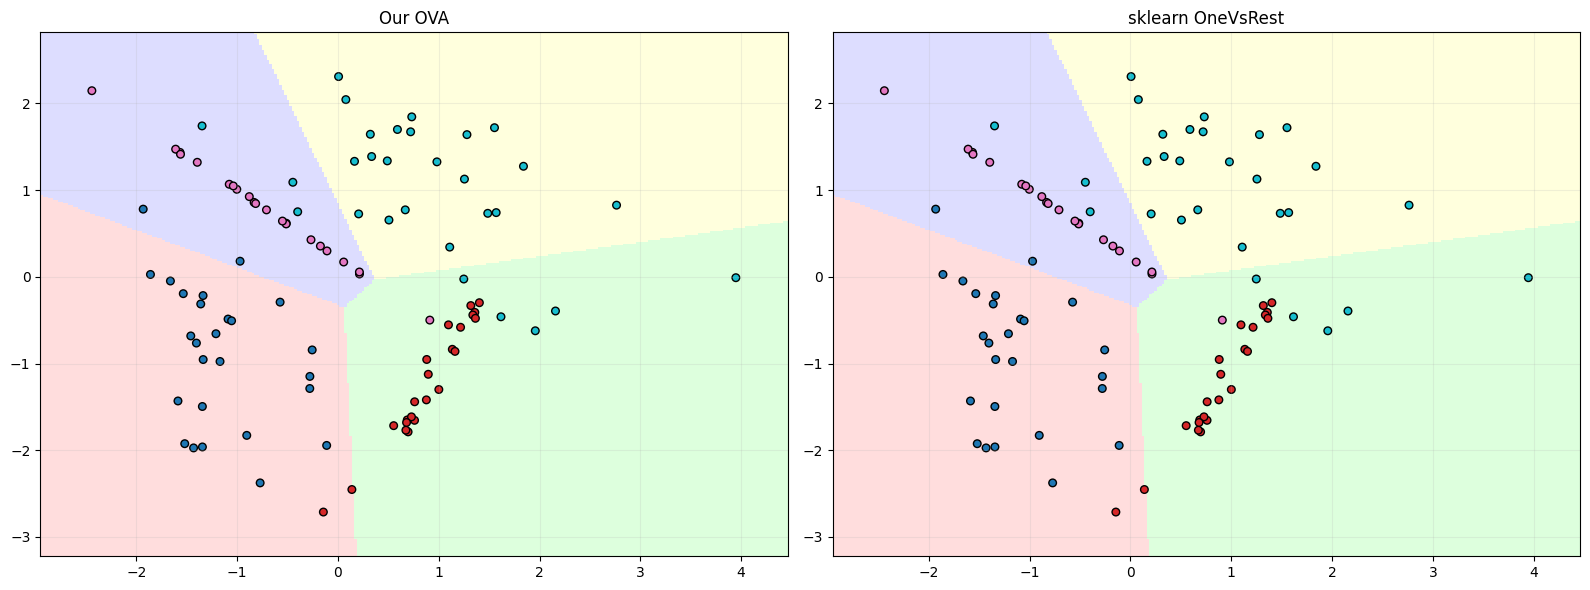

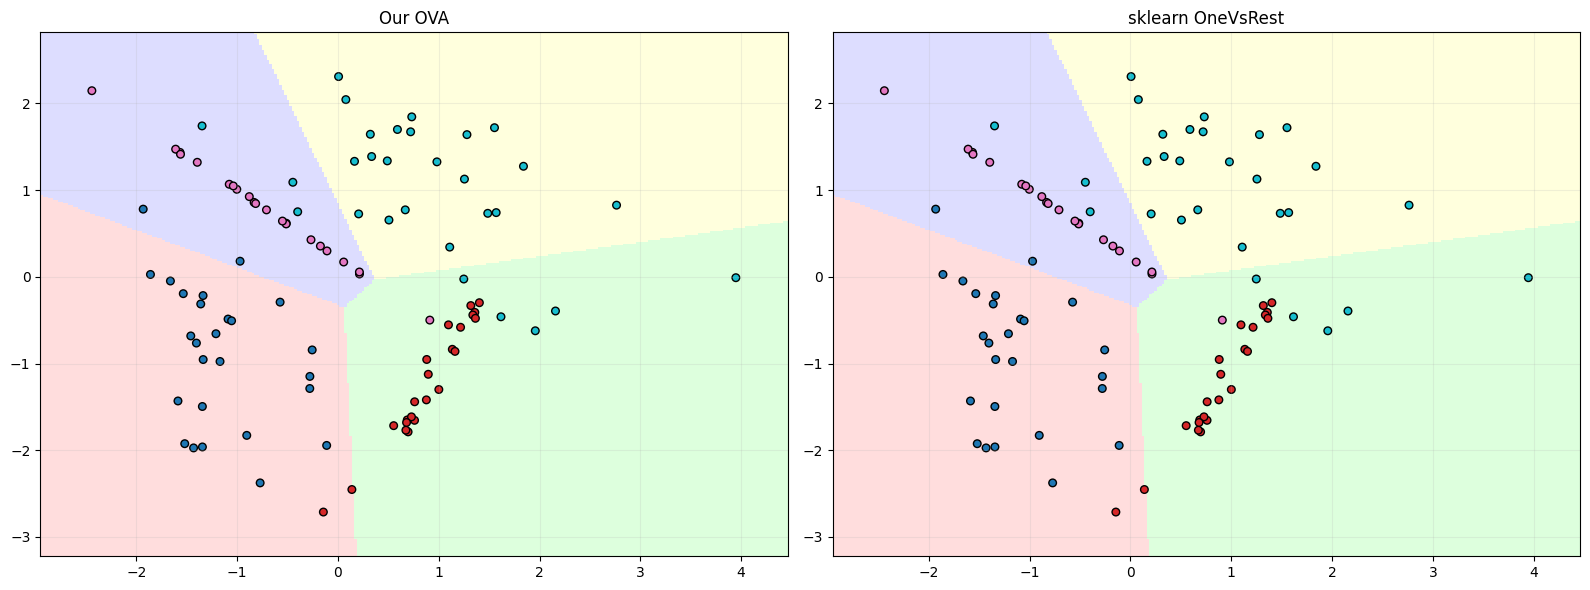

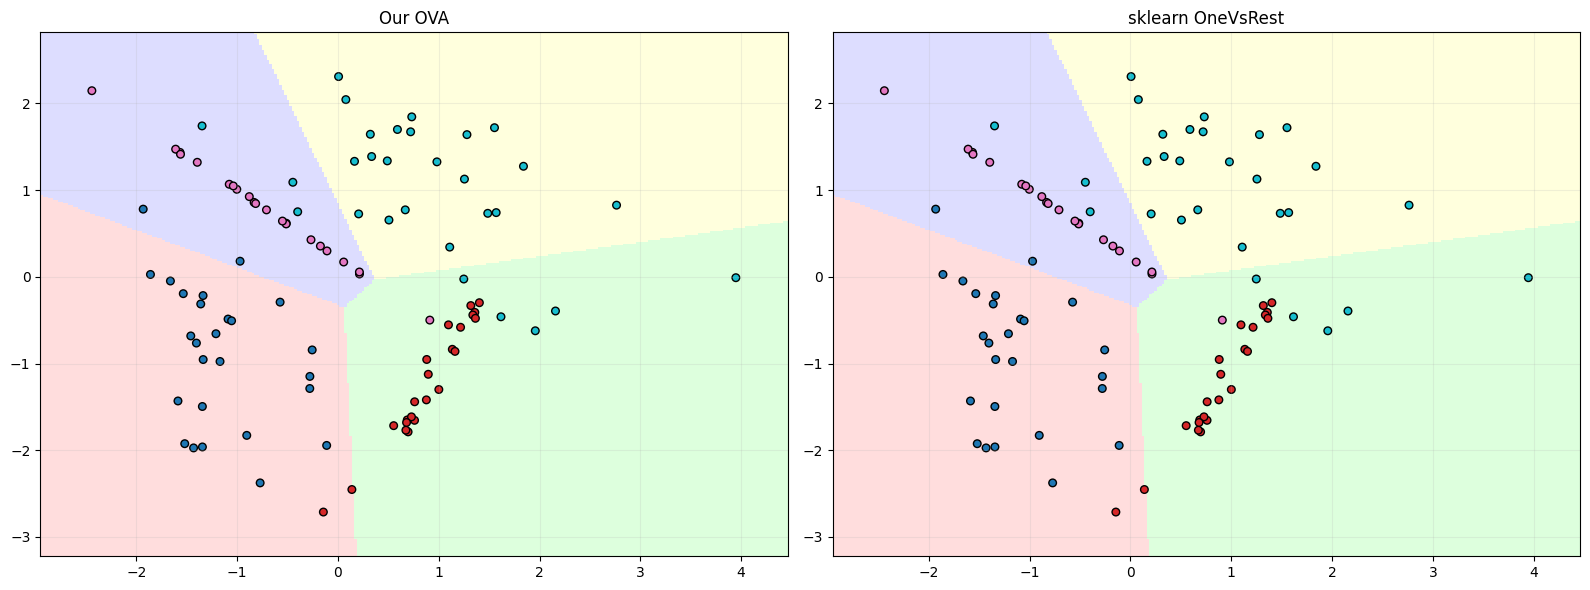

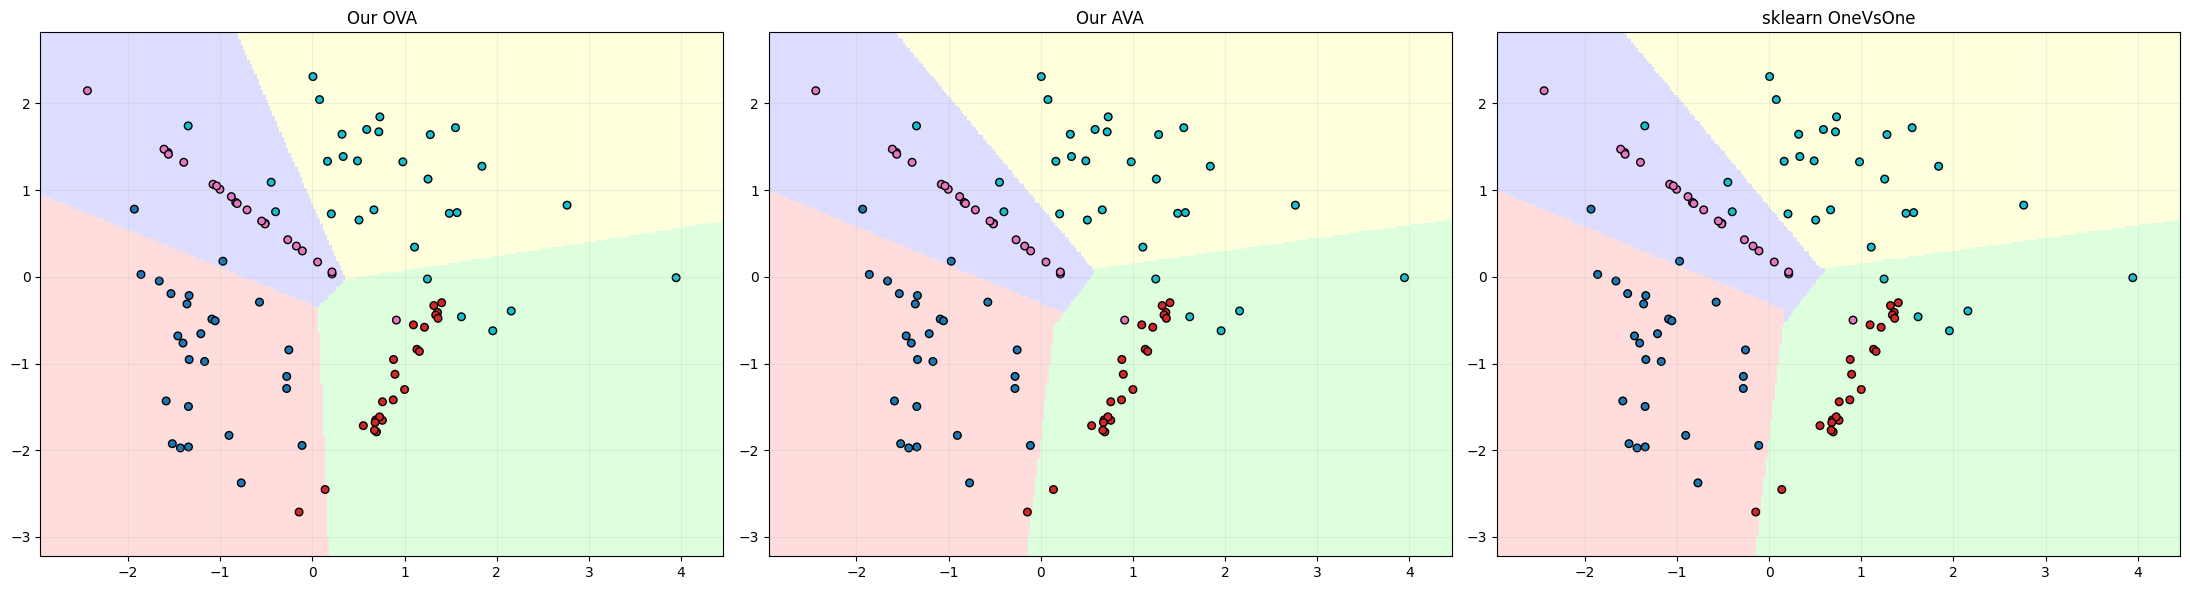

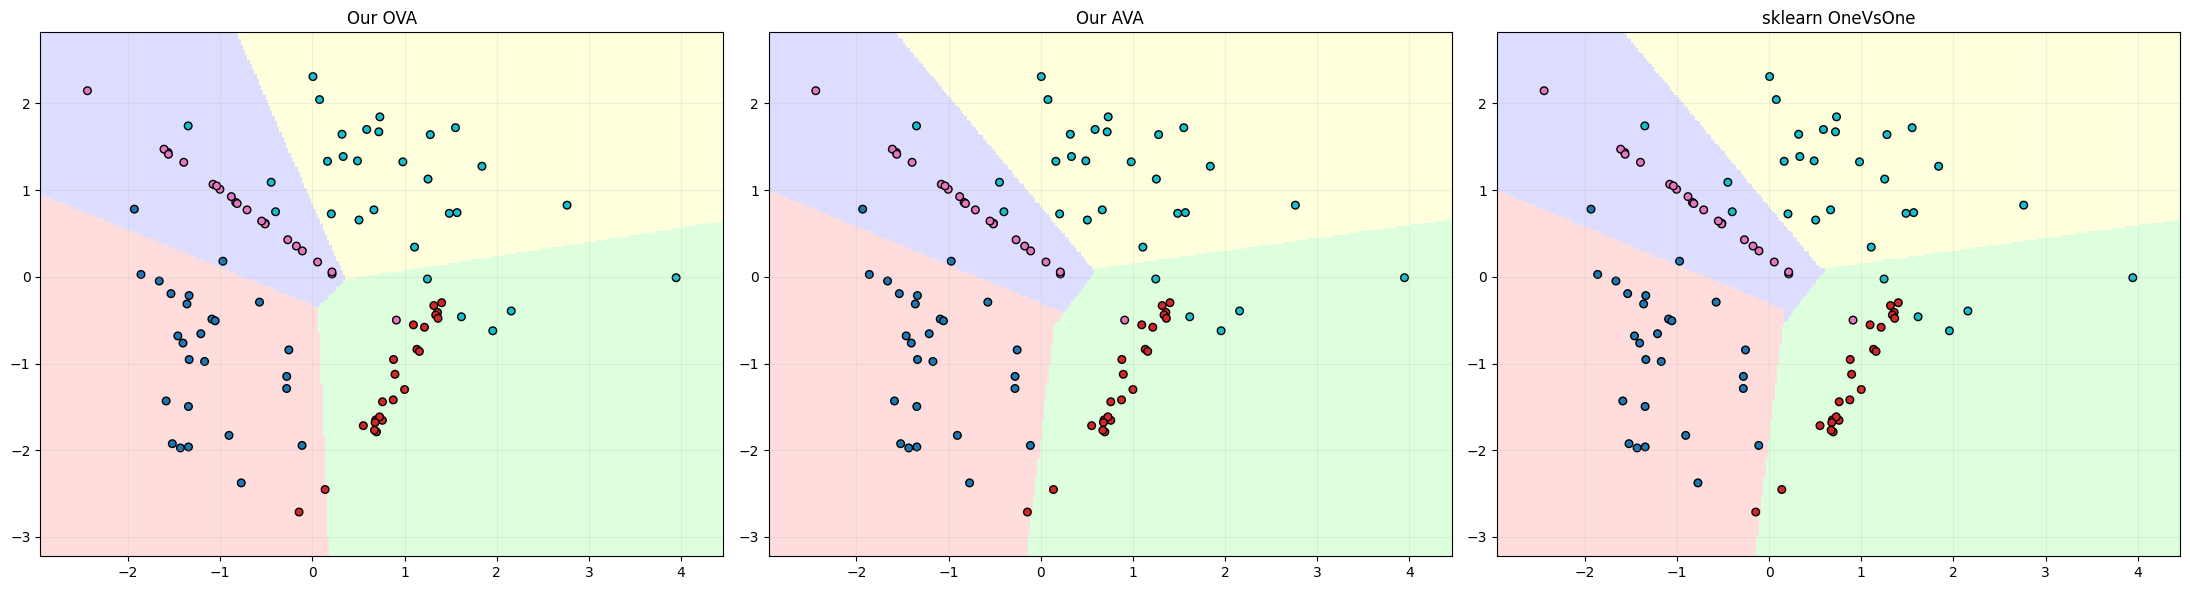

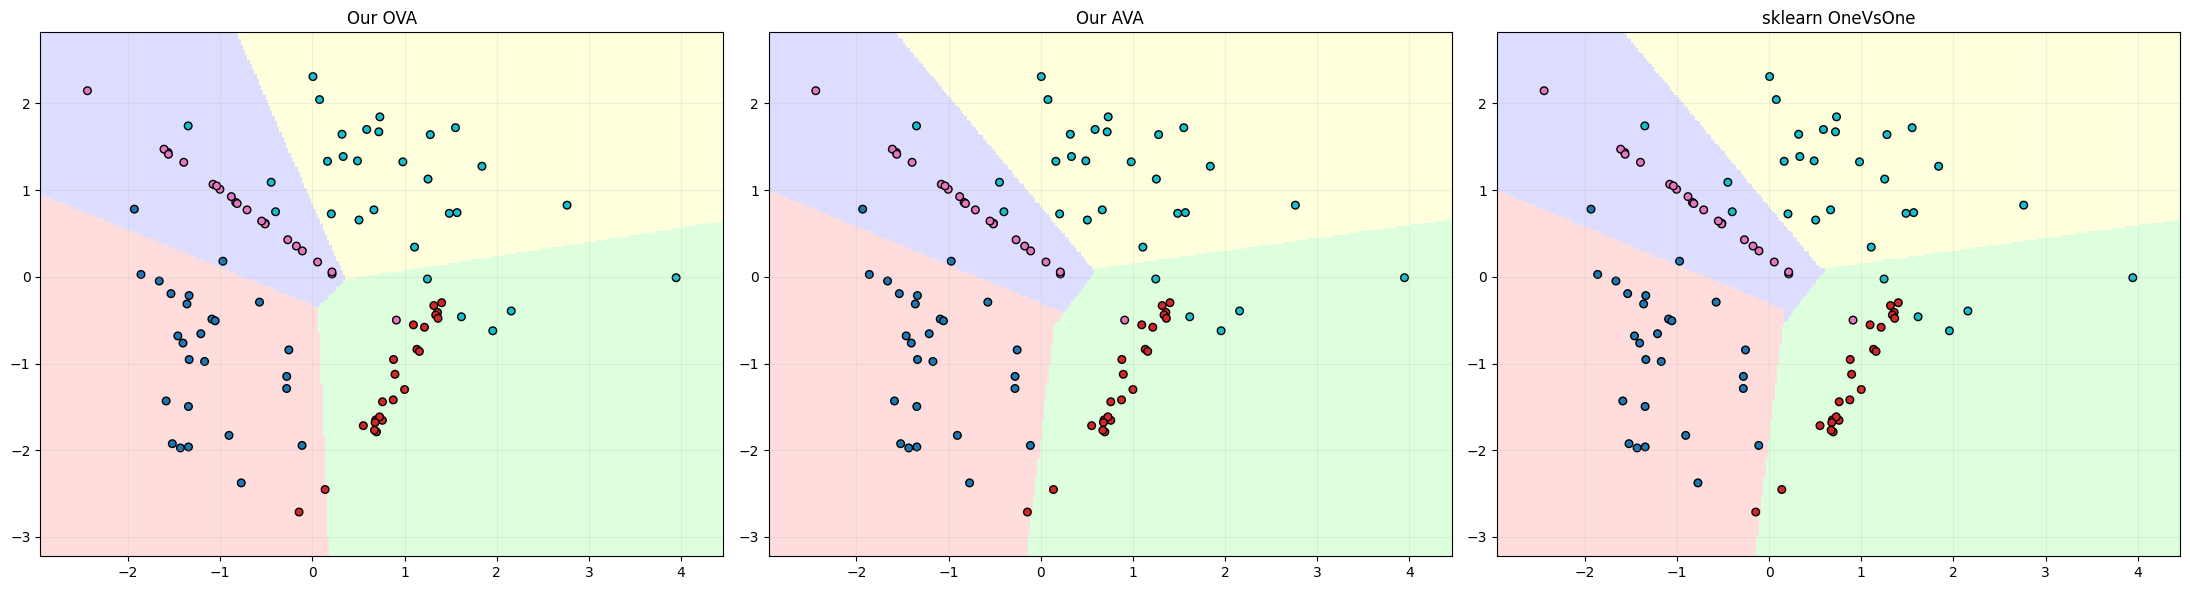

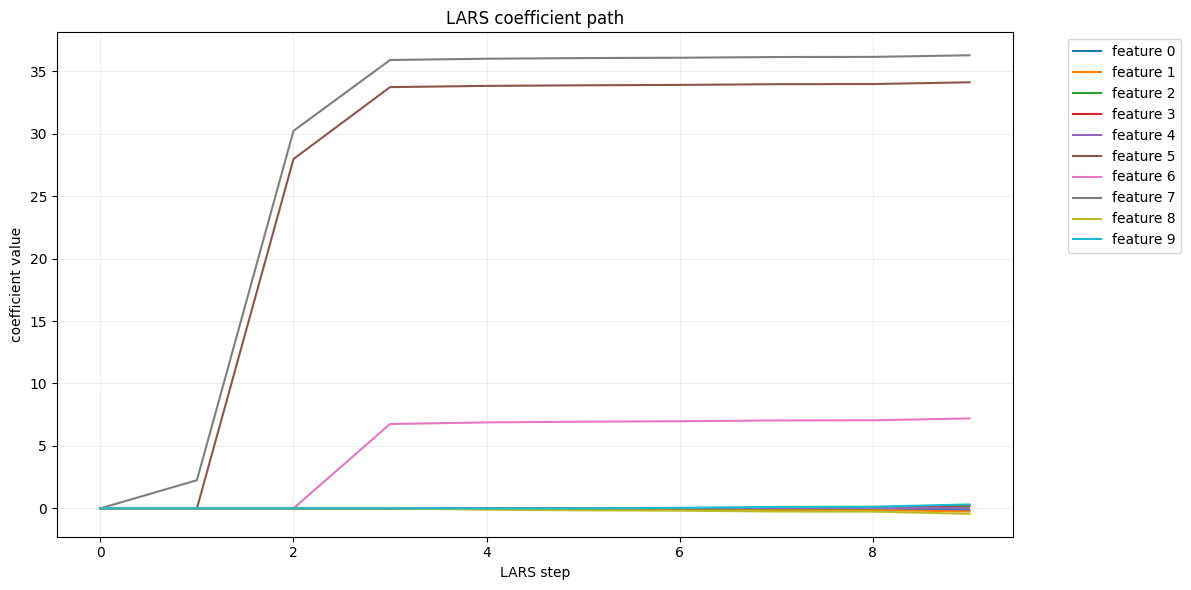

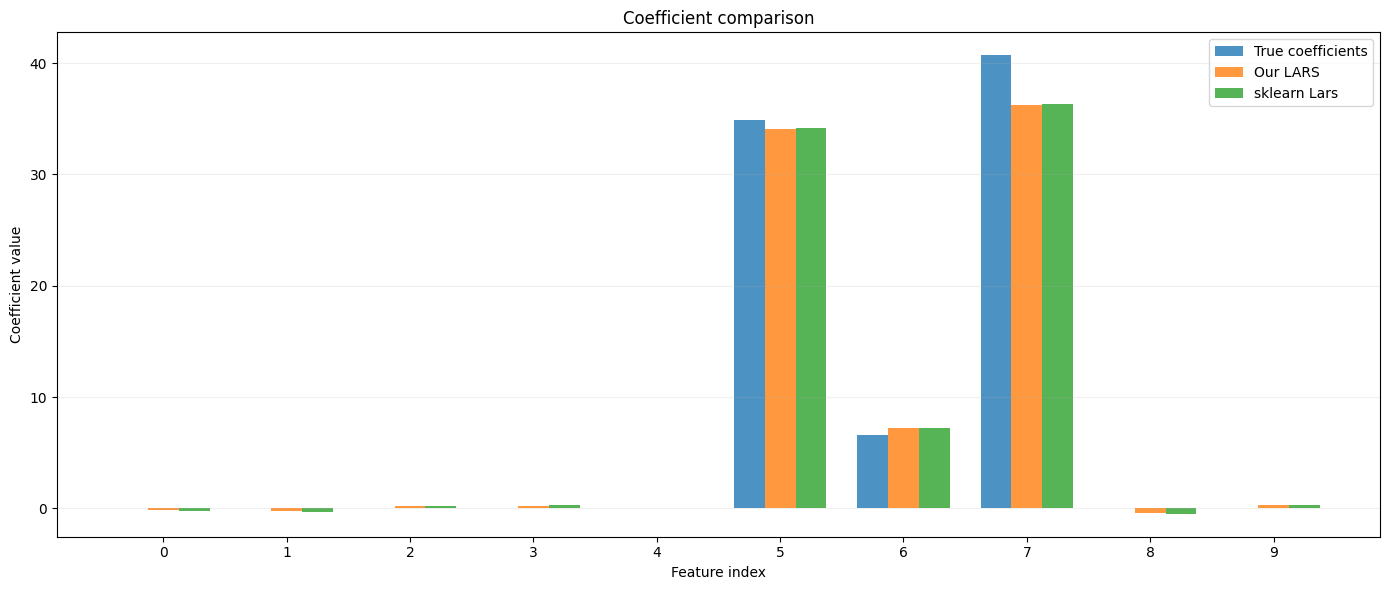

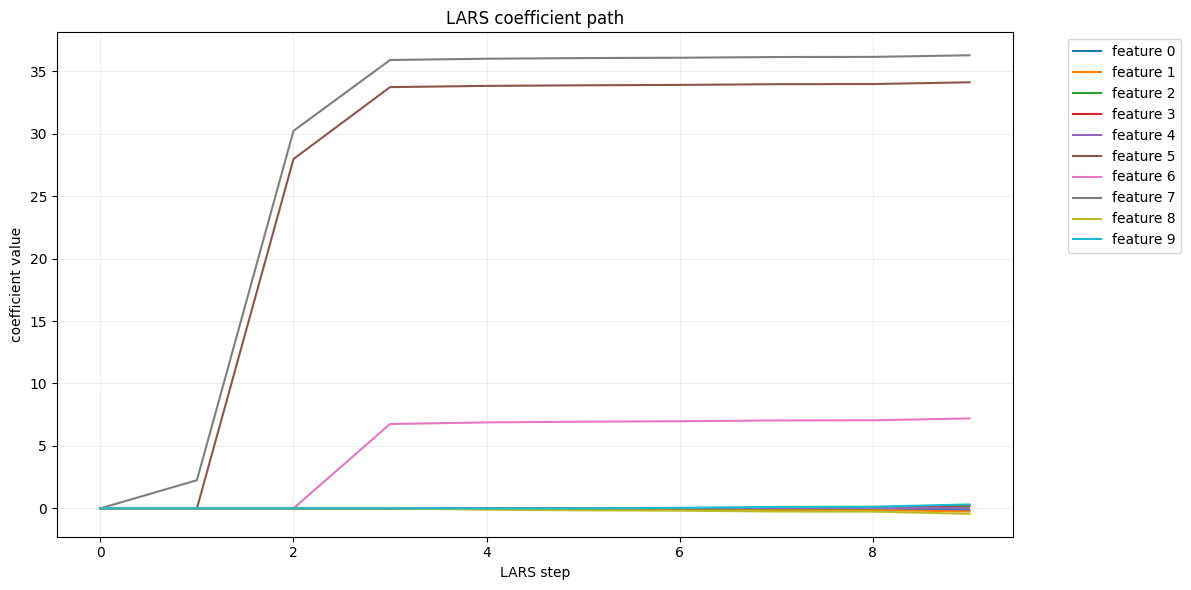

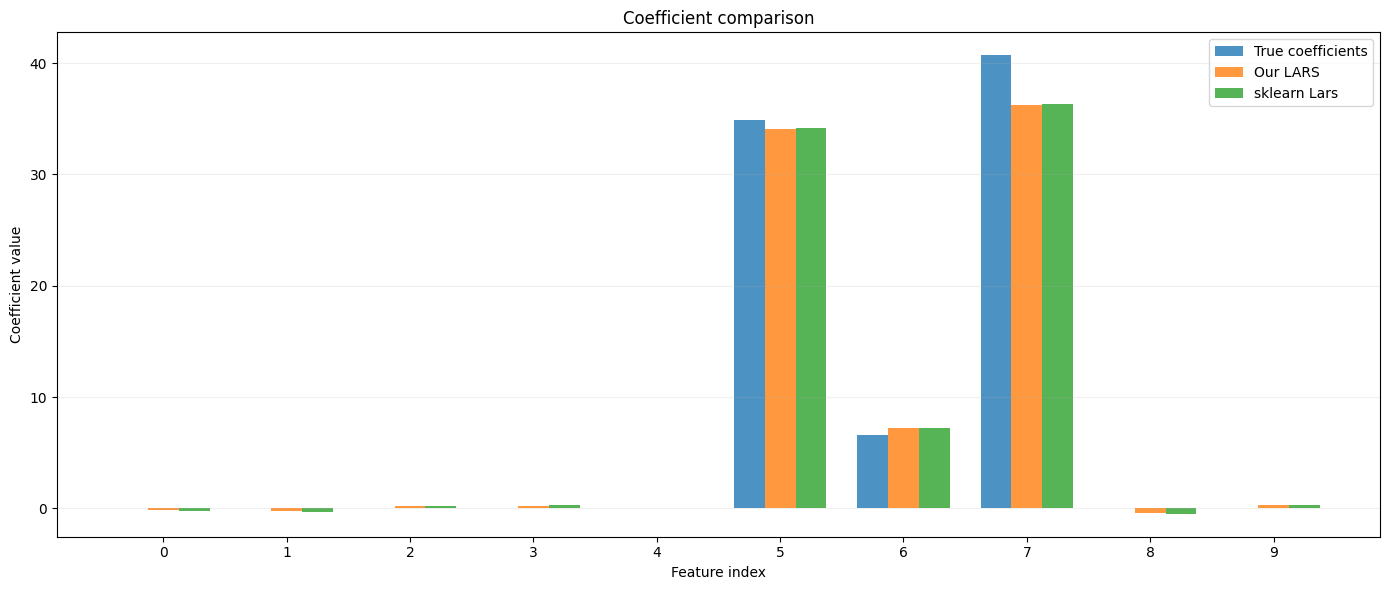

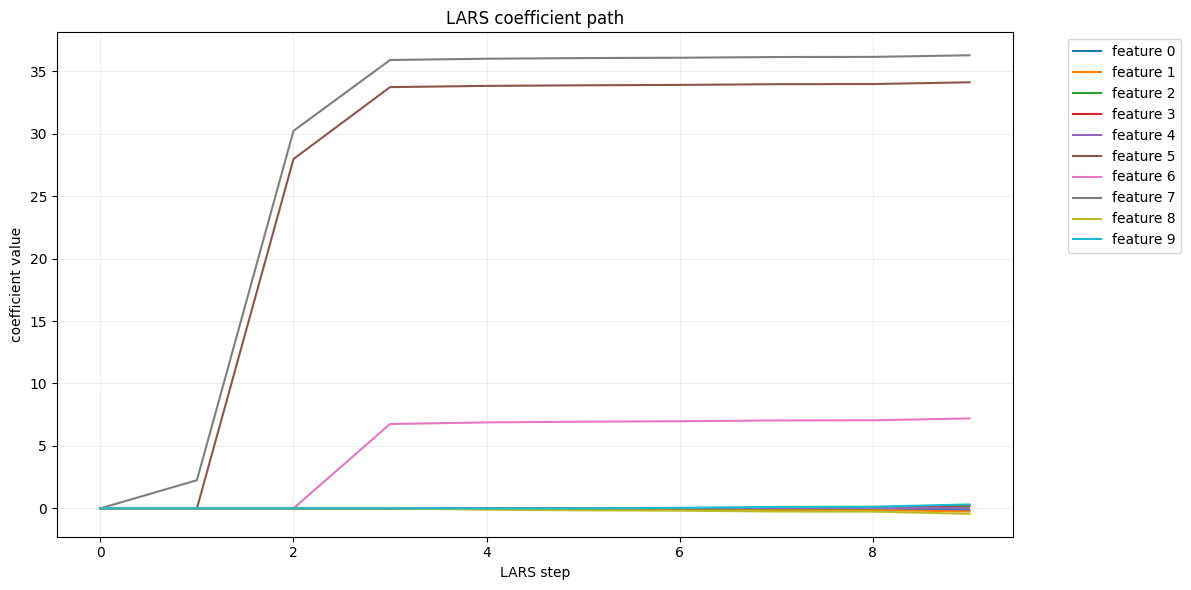

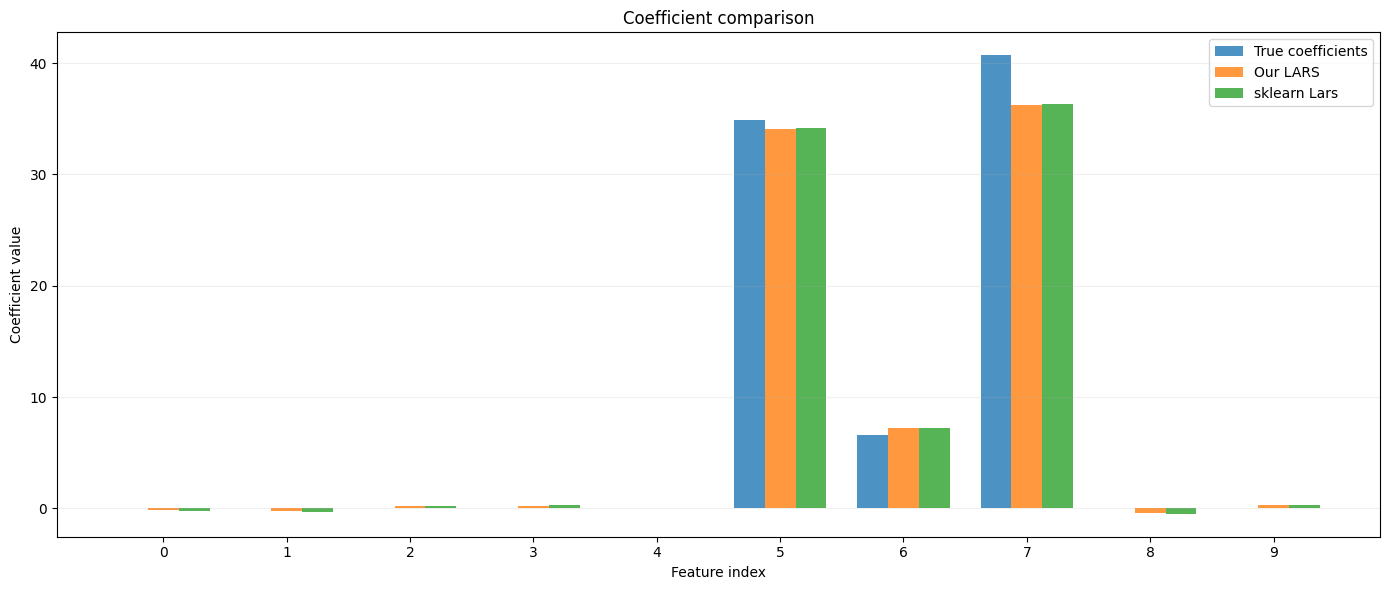

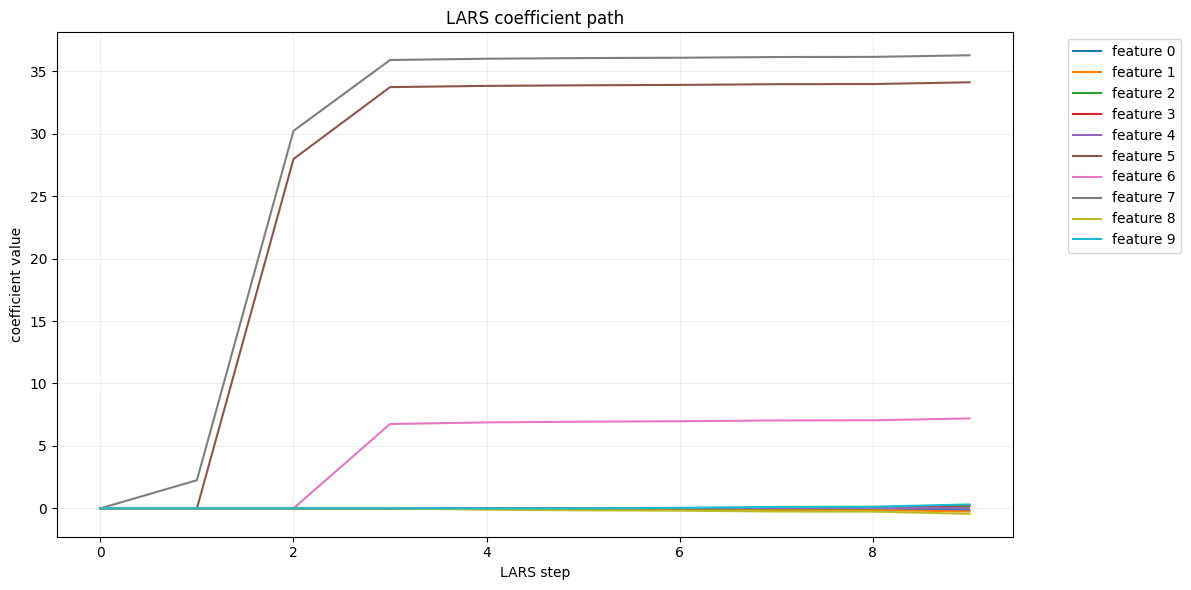

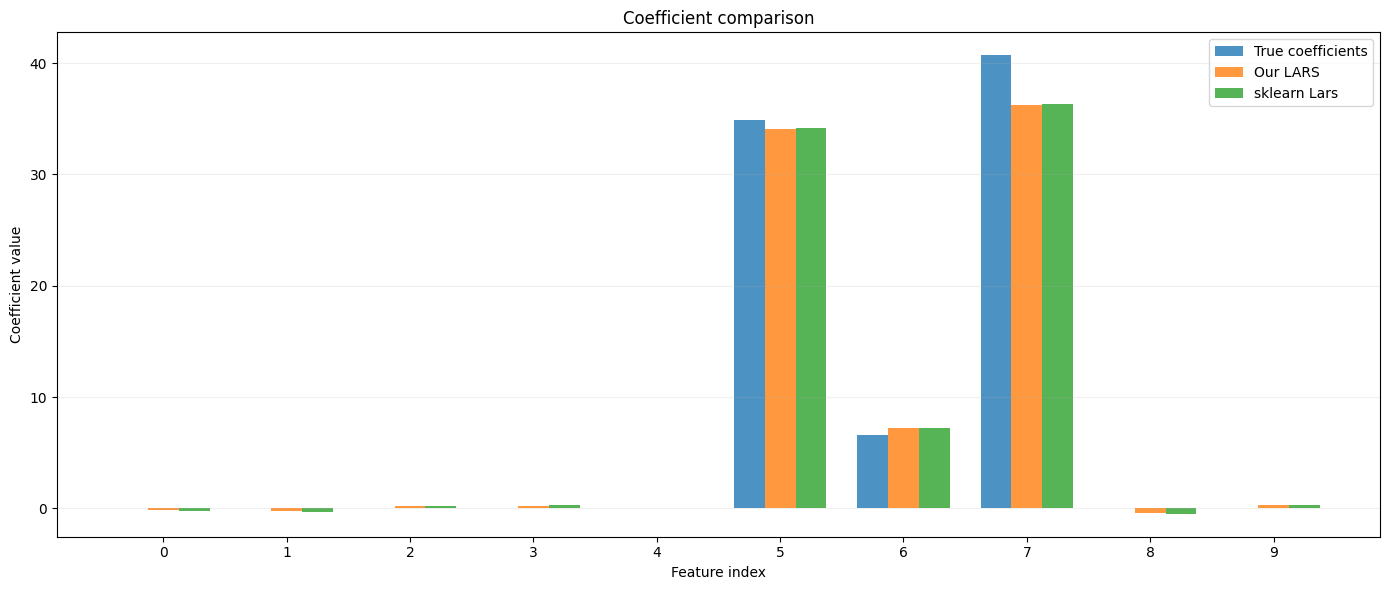

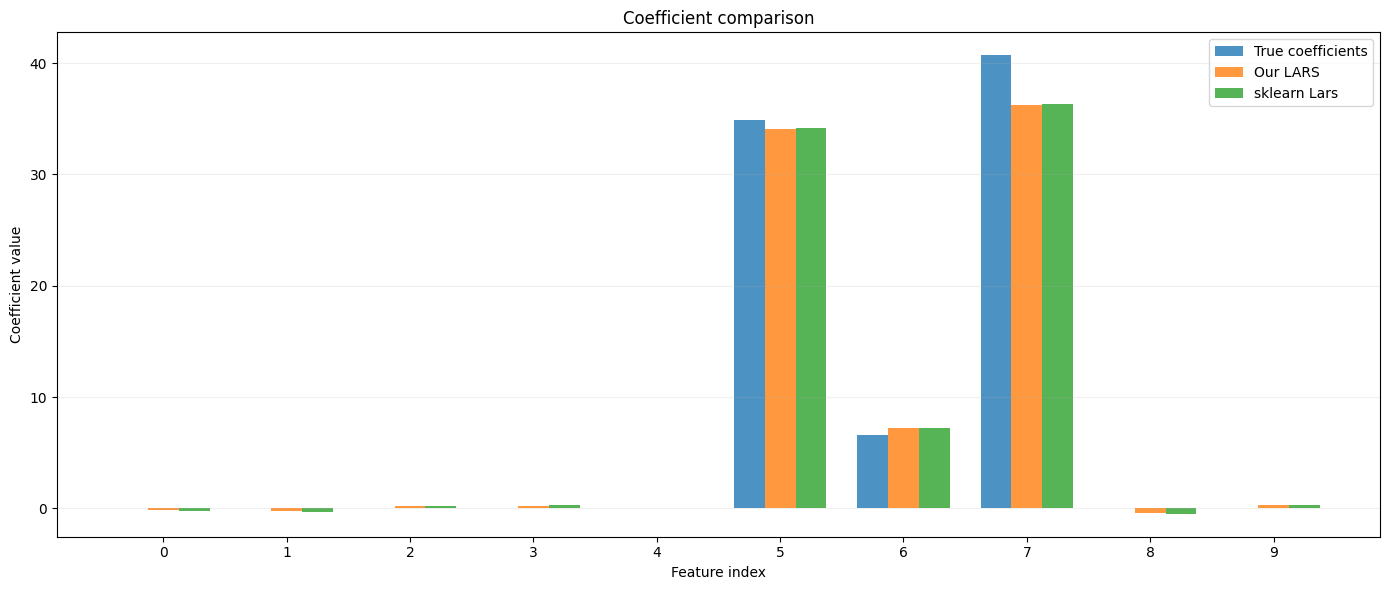

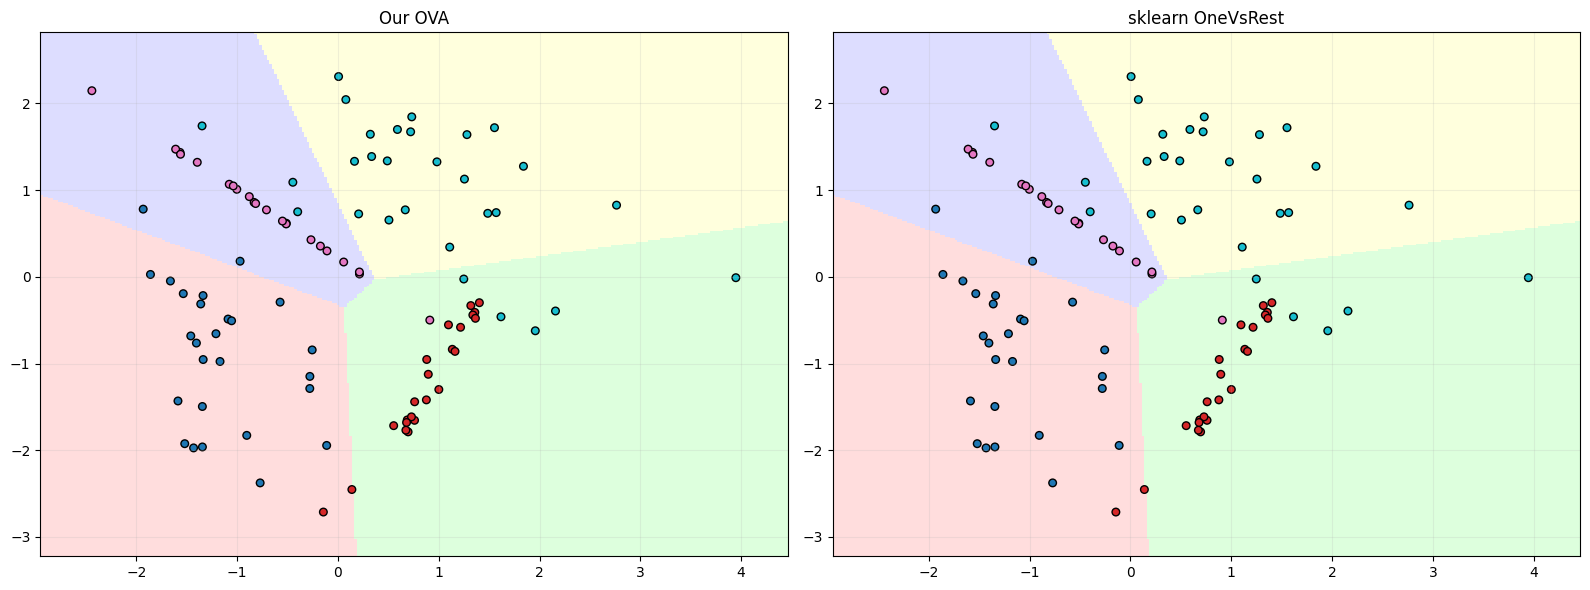

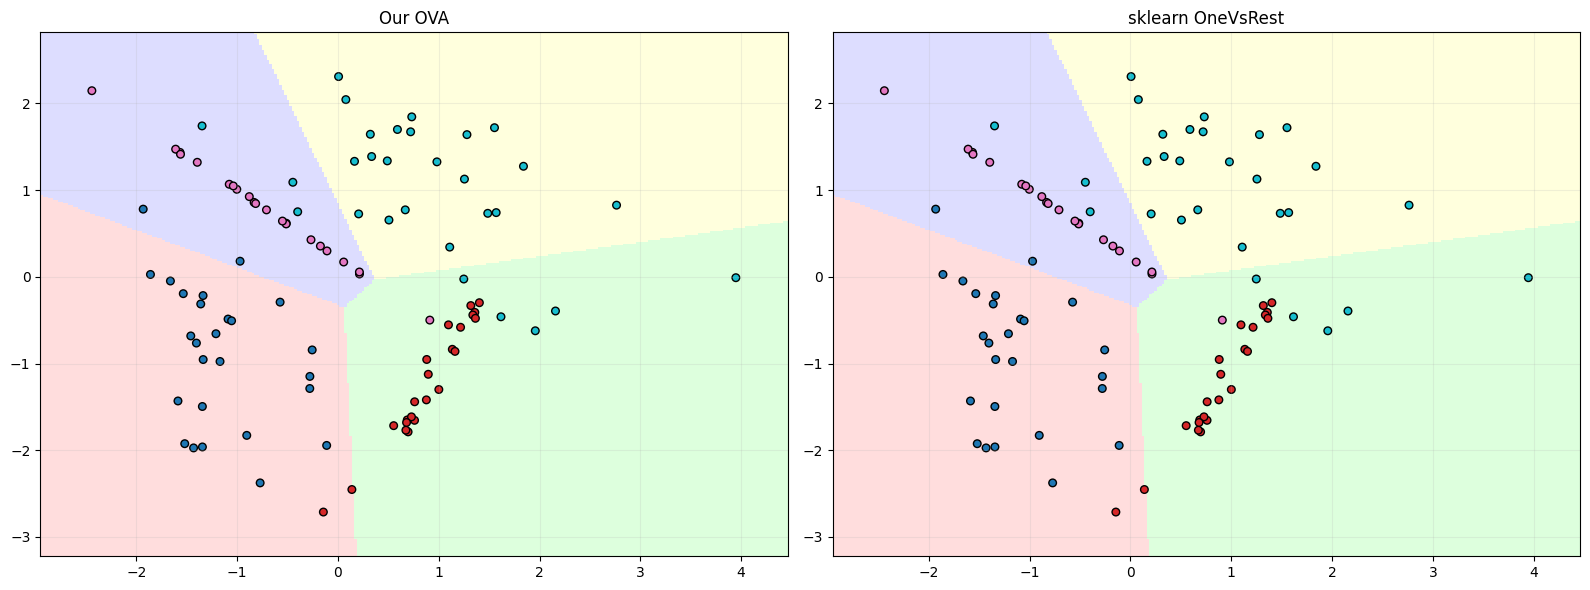

Our OVA accuracy:     0.870
sklearn OVR accuracy: 0.870


In [80]:
if __name__ != "homework":
    from sklearn.multiclass import OneVsRestClassifier

    ova = OVAClassifier(LogisticRegression(max_iter=1000))
    ova.fit(X_vis_train, y_vis_train)
    ova_preds = ova.predict(X_vis_test)

    sk_ova = OneVsRestClassifier(LogisticRegression(max_iter=1000))
    sk_ova.fit(X_vis_train, y_vis_train)
    sk_ova_preds = sk_ova.predict(X_vis_test)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plot_decision_boundary(ova, X_vis_test, y_vis_test, axes[0], 'Our OVA')
    plot_decision_boundary(sk_ova, X_vis_test, y_vis_test, axes[1], 'sklearn OneVsRest')
    plt.tight_layout()
    %matplotlib inline
    plt.show()

    print(f'Our OVA accuracy:     {accuracy_score(y_vis_test, ova_preds):.3f}')
    print(f'sklearn OVR accuracy: {accuracy_score(y_vis_test, sk_ova_preds):.3f}')

## 2. All-vs-All (AVA)

Стратегия AVA (она же One-vs-One, OVO):
- Для задачи с K классами обучаем $\frac{K(K-1)}{2}$ бинарных классификаторов
- Классификатор $(i, j)$ обучается только на объектах классов $i$ и $j$
- При предсказании каждый классификатор голосует за один из своих двух классов
- Побеждает класс с наибольшим числом голосов

AVA обучает больше классификаторов, но каждый на меньшем подмножестве данных.

In [81]:
class AVAClassifier:
    def __init__(self, base_clf=None):
        self.base_clf = base_clf if base_clf is not None else LogisticRegression(max_iter=1000)
        self.classes_ = None
        self.classifiers_ = []

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.classifiers_ = []

        for class_i, class_j in combinations(self.classes_, 2):
            mask = (y == class_i) | (y == class_j)
            X_pair = X[mask]
            y_pair = y[mask]

            clf = clone(self.base_clf)
            clf.fit(X_pair, y_pair)
            self.classifiers_.append((clf, class_i, class_j))

        return self

    def predict(self, X):
        votes = np.zeros((X.shape[0], len(self.classes_)), dtype=int)
        class_to_idx = {cls: idx for idx, cls in enumerate(self.classes_)}

        for clf, class_i, class_j in self.classifiers_:
            preds = clf.predict(X)
            for k, pred in enumerate(preds):
                votes[k, class_to_idx[pred]] += 1

        return self.classes_[np.argmax(votes, axis=1)]


### Проверка AVA

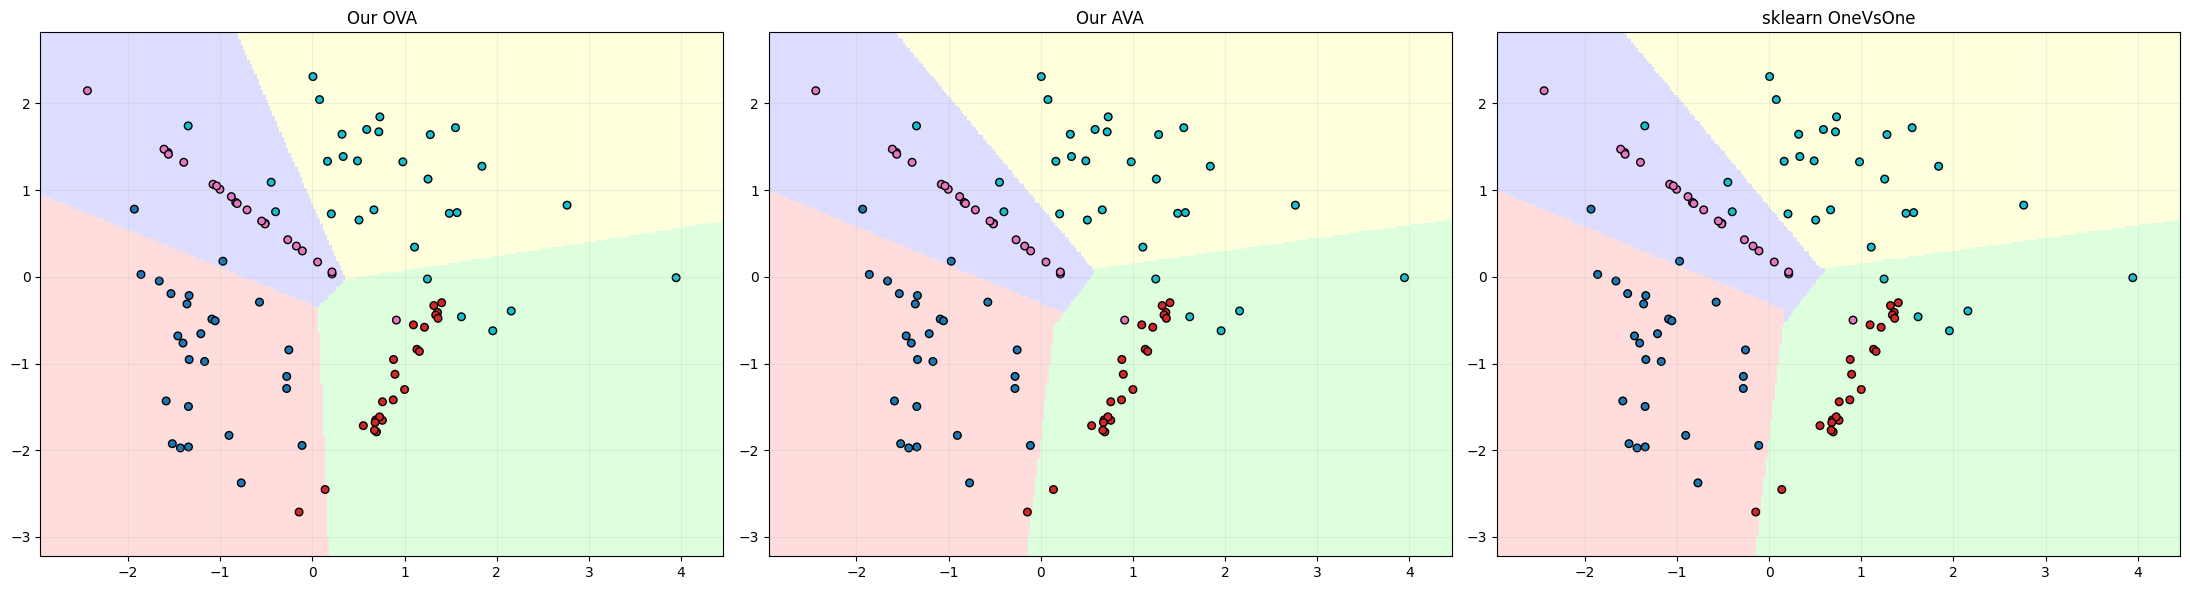

Our OVA accuracy:     0.870
Our AVA accuracy:     0.880
sklearn OVO accuracy: 0.880


In [82]:
if __name__ != "homework":
    from sklearn.multiclass import OneVsOneClassifier

    ava = AVAClassifier(LogisticRegression(max_iter=1000))
    ava.fit(X_vis_train, y_vis_train)
    ava_preds = ava.predict(X_vis_test)

    sk_ava = OneVsOneClassifier(LogisticRegression(max_iter=1000))
    sk_ava.fit(X_vis_train, y_vis_train)
    sk_ava_preds = sk_ava.predict(X_vis_test)

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    plot_decision_boundary(ova, X_vis_test, y_vis_test, axes[0], 'Our OVA')
    plot_decision_boundary(ava, X_vis_test, y_vis_test, axes[1], 'Our AVA')
    plot_decision_boundary(sk_ava, X_vis_test, y_vis_test, axes[2], 'sklearn OneVsOne')
    %matplotlib inline
    plt.tight_layout()
    plt.show()

    print(f'Our OVA accuracy:     {accuracy_score(y_vis_test, ova_preds):.3f}')
    print(f'Our AVA accuracy:     {accuracy_score(y_vis_test, ava_preds):.3f}')
    print(f'sklearn OVO accuracy: {accuracy_score(y_vis_test, sk_ava_preds):.3f}')

## 3. LARS (Least Angle Regression)

LARS - алгоритм, который строит путь регрессионных коэффициентов от нуля до полного OLS-решения. На каждом шаге он добавляет в модель один признак.

Алгоритм:
1. Начинаем с $w = 0$, остаток $r = y$
2. Находим признак $x_j$, наиболее коррелированный с остатком $r$
3. Двигаем коэффициент $w_j$ в направлении корреляции, пока другой признак $x_k$ не станет столь же коррелированным с остатком
4. Двигаем оба коэффициента в equiangular direction (направлении равных углов)
5. Повторяем, пока не будут задействованы все признаки или не достигнут лимит `n_features`

**Важно:** данные должны быть стандартизированы (mean=0) перед подачей в LARS.

In [83]:
class LARS:
    def __init__(self, n_features=None):
        self.n_features = n_features

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_samples, n_total_features = X.shape
        max_features = n_total_features if self.n_features is None else min(self.n_features, n_total_features)

        self.coef_ = np.zeros(n_total_features, dtype=float)
        self.intercept_ = 0.0
        self.coef_path_ = [self.coef_.copy()]

        mu = np.zeros(n_samples, dtype=float)
        active = []
        active_signs = []
        eps = 1e-12

        while len(active) < max_features:
            residual = y - mu
            c = X.T @ residual

            inactive = [j for j in range(n_total_features) if j not in active]
            if not inactive:
                break

            C = np.max(np.abs(c[inactive]))
            if C < eps:
                break

            j = inactive[np.argmax(np.abs(c[inactive]))]
            active.append(j)
            active_signs.append(np.sign(c[j]) if np.sign(c[j]) != 0 else 1.0)

            X_A = X[:, active] * np.array(active_signs)
            G_A = X_A.T @ X_A
            G_A_inv = np.linalg.pinv(G_A)

            ones = np.ones(len(active))
            A_A = 1.0 / np.sqrt(ones @ G_A_inv @ ones)
            w_A = A_A * (G_A_inv @ ones)
            u_A = X_A @ w_A

            a = X.T @ u_A

            gamma_candidates = []
            for j_inactive in inactive:
                if j_inactive == j:
                    continue

                denom1 = A_A - a[j_inactive]
                denom2 = A_A + a[j_inactive]

                if abs(denom1) > eps:
                    gamma1 = (C - c[j_inactive]) / denom1
                    if gamma1 > eps:
                        gamma_candidates.append(gamma1)

                if abs(denom2) > eps:
                    gamma2 = (C + c[j_inactive]) / denom2
                    if gamma2 > eps:
                        gamma_candidates.append(gamma2)

            gamma = min(gamma_candidates) if gamma_candidates else C / A_A

            mu = mu + gamma * u_A
            self.coef_[active] = self.coef_[active] + gamma * w_A * np.array(active_signs)
            self.coef_path_.append(self.coef_.copy())

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.coef_ + self.intercept_


### Проверка LARS

In [84]:
if __name__ != "homework":
    # Sparse regression: 10 features, only 3 informative
    X_lars, y_lars, true_coef = make_regression(
        n_samples=200, n_features=10, n_informative=3,
        noise=5.0, coef=True, random_state=42,
    )
    # Standardize
    X_lars = (X_lars - X_lars.mean(axis=0)) / X_lars.std(axis=0)
    y_lars = y_lars - y_lars.mean()

In [85]:
if __name__ != "homework":
    from sklearn.linear_model import Lars as SkLars

    lars = LARS()
    lars.fit(X_lars, y_lars)

    sk_lars = SkLars().fit(X_lars, y_lars)

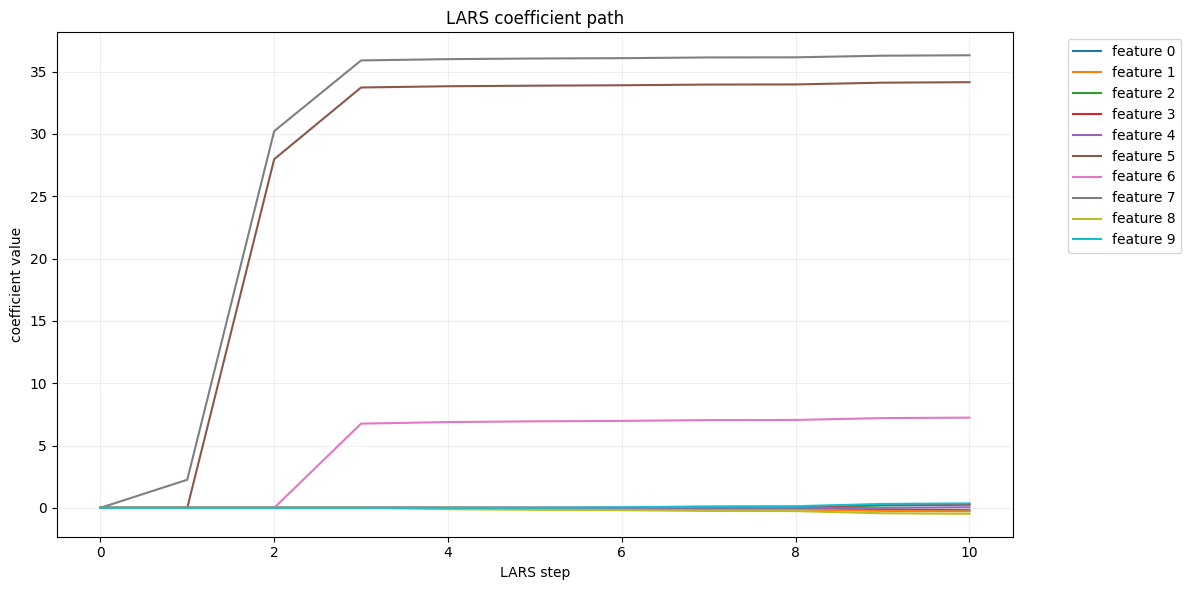

In [86]:
if __name__ != "homework":
    # Coefficient path: features entering the model one by one
    path = np.array(lars.coef_path_)

    plt.figure(figsize=(12, 6))
    for j in range(path.shape[1]):
        plt.plot(path[:, j], label=f'feature {j}')
    plt.xlabel('LARS step')
    plt.ylabel('coefficient value')
    plt.title('LARS coefficient path')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.2)
    %matplotlib inline
    plt.tight_layout()
    plt.show()

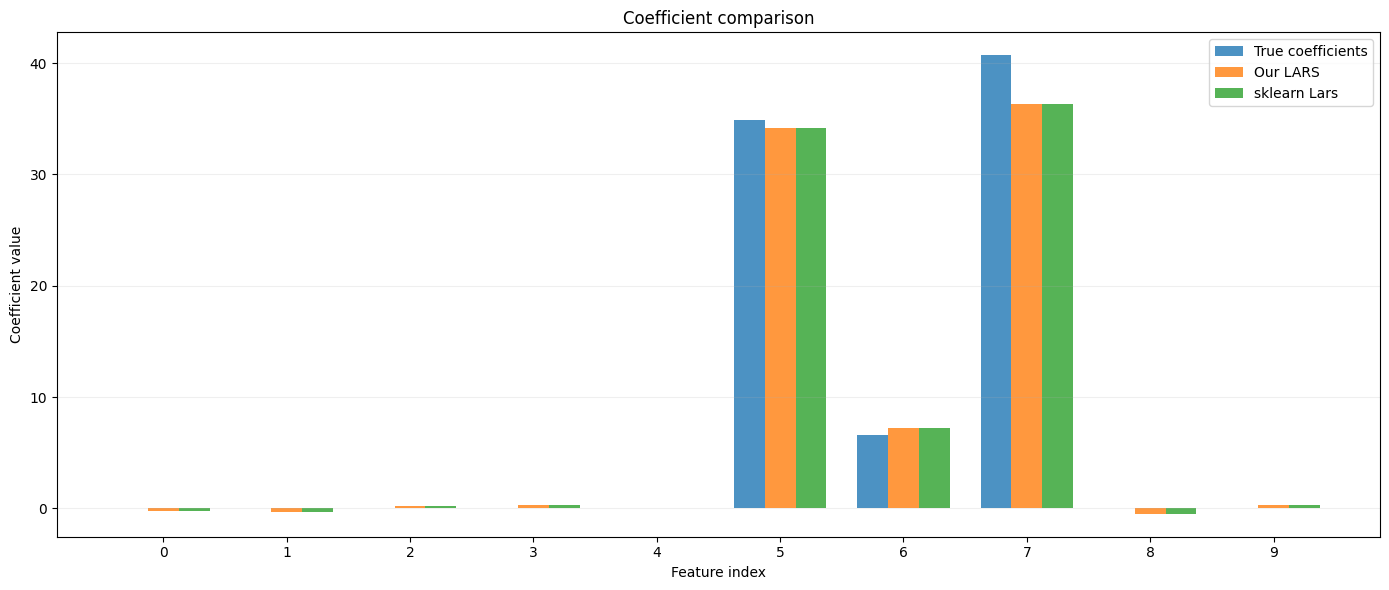

Our LARS MSE:    21.4414
sklearn Lars MSE: 21.4414


In [87]:
if __name__ != "homework":
    # Compare final coefficients: ours vs sklearn vs true
    feat_idx = np.arange(X_lars.shape[1])
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(feat_idx - width, true_coef, width, label='True coefficients', alpha=0.8)
    ax.bar(feat_idx, lars.coef_, width, label='Our LARS', alpha=0.8)
    ax.bar(feat_idx + width, sk_lars.coef_, width, label='sklearn Lars', alpha=0.8)
    ax.set_xlabel('Feature index')
    ax.set_ylabel('Coefficient value')
    ax.set_title('Coefficient comparison')
    ax.set_xticks(feat_idx)
    ax.legend()
    ax.grid(alpha=0.2, axis='y')
    %matplotlib inline
    plt.tight_layout()
    plt.show()

    our_mse = np.mean((lars.predict(X_lars) - y_lars) ** 2)
    sk_mse = np.mean((sk_lars.predict(X_lars) - y_lars) ** 2)
    print(f'Our LARS MSE:    {our_mse:.4f}')
    print(f'sklearn Lars MSE: {sk_mse:.4f}')